# DINO

## Documentación

https://huggingface.co/docs/transformers/model_doc/dinov2

## Importar librerías

In [55]:
from transformers import AutoImageProcessor, AutoModel
import torch
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

In [107]:
dataset_path = os.environ['OUTPUT_DIR']

In [85]:
image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.png', '.jpeg', '.webp'))]

In [61]:
# DINO model
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModel.from_pretrained('facebook/dinov2-base')

In [87]:
# Extaer features
def extract_features(image, model, processor):
     # Abrir y preprocesar imagen
    image = Image.open(image).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    
    # Extrae features
    with torch.no_grad():
        outputs = model(**inputs)
        features = outputs.last_hidden_state.mean(dim=1).detach().cpu().numpy()
    
    return features


In [93]:
features_list = []
for image_file in image_files:
    image_path = os.path.join(dataset_path, image_file)  
    print(f"Procesando: {image_path}") 
    try:
        features = extract_features(image_path, model, processor)
        features_list.append(features)
    except FileNotFoundError as e:
        print(f"Error: {e}")

print(f"Total de imágenes procesadas: {len(features_list)}")

Procesando: /root/work/_Results/test_01-Scene-001-01.webp
Procesando: /root/work/_Results/test_01-Scene-001-02.webp
Procesando: /root/work/_Results/test_01-Scene-001-03.webp
Procesando: /root/work/_Results/test_01-Scene-002-01.webp
Procesando: /root/work/_Results/test_01-Scene-002-02.webp
Procesando: /root/work/_Results/test_01-Scene-002-03.webp
Procesando: /root/work/_Results/test_01-Scene-003-01.webp
Procesando: /root/work/_Results/test_01-Scene-003-02.webp
Procesando: /root/work/_Results/test_01-Scene-003-03.webp
Procesando: /root/work/_Results/test_01-Scene-004-01.webp
Procesando: /root/work/_Results/test_01-Scene-004-02.webp
Procesando: /root/work/_Results/test_01-Scene-004-03.webp
Procesando: /root/work/_Results/test_01-Scene-005-01.webp
Procesando: /root/work/_Results/test_01-Scene-005-02.webp
Procesando: /root/work/_Results/test_01-Scene-005-03.webp
Procesando: /root/work/_Results/test_01-Scene-006-01.webp
Procesando: /root/work/_Results/test_01-Scene-006-02.webp
Procesando: /r

In [99]:
# Esto es para crear una matrix de similitud
flattened_features = [feature.flatten() for feature in features_list]

# Calcular similitud
similarity_matrix = cosine_similarity(flattened_features)


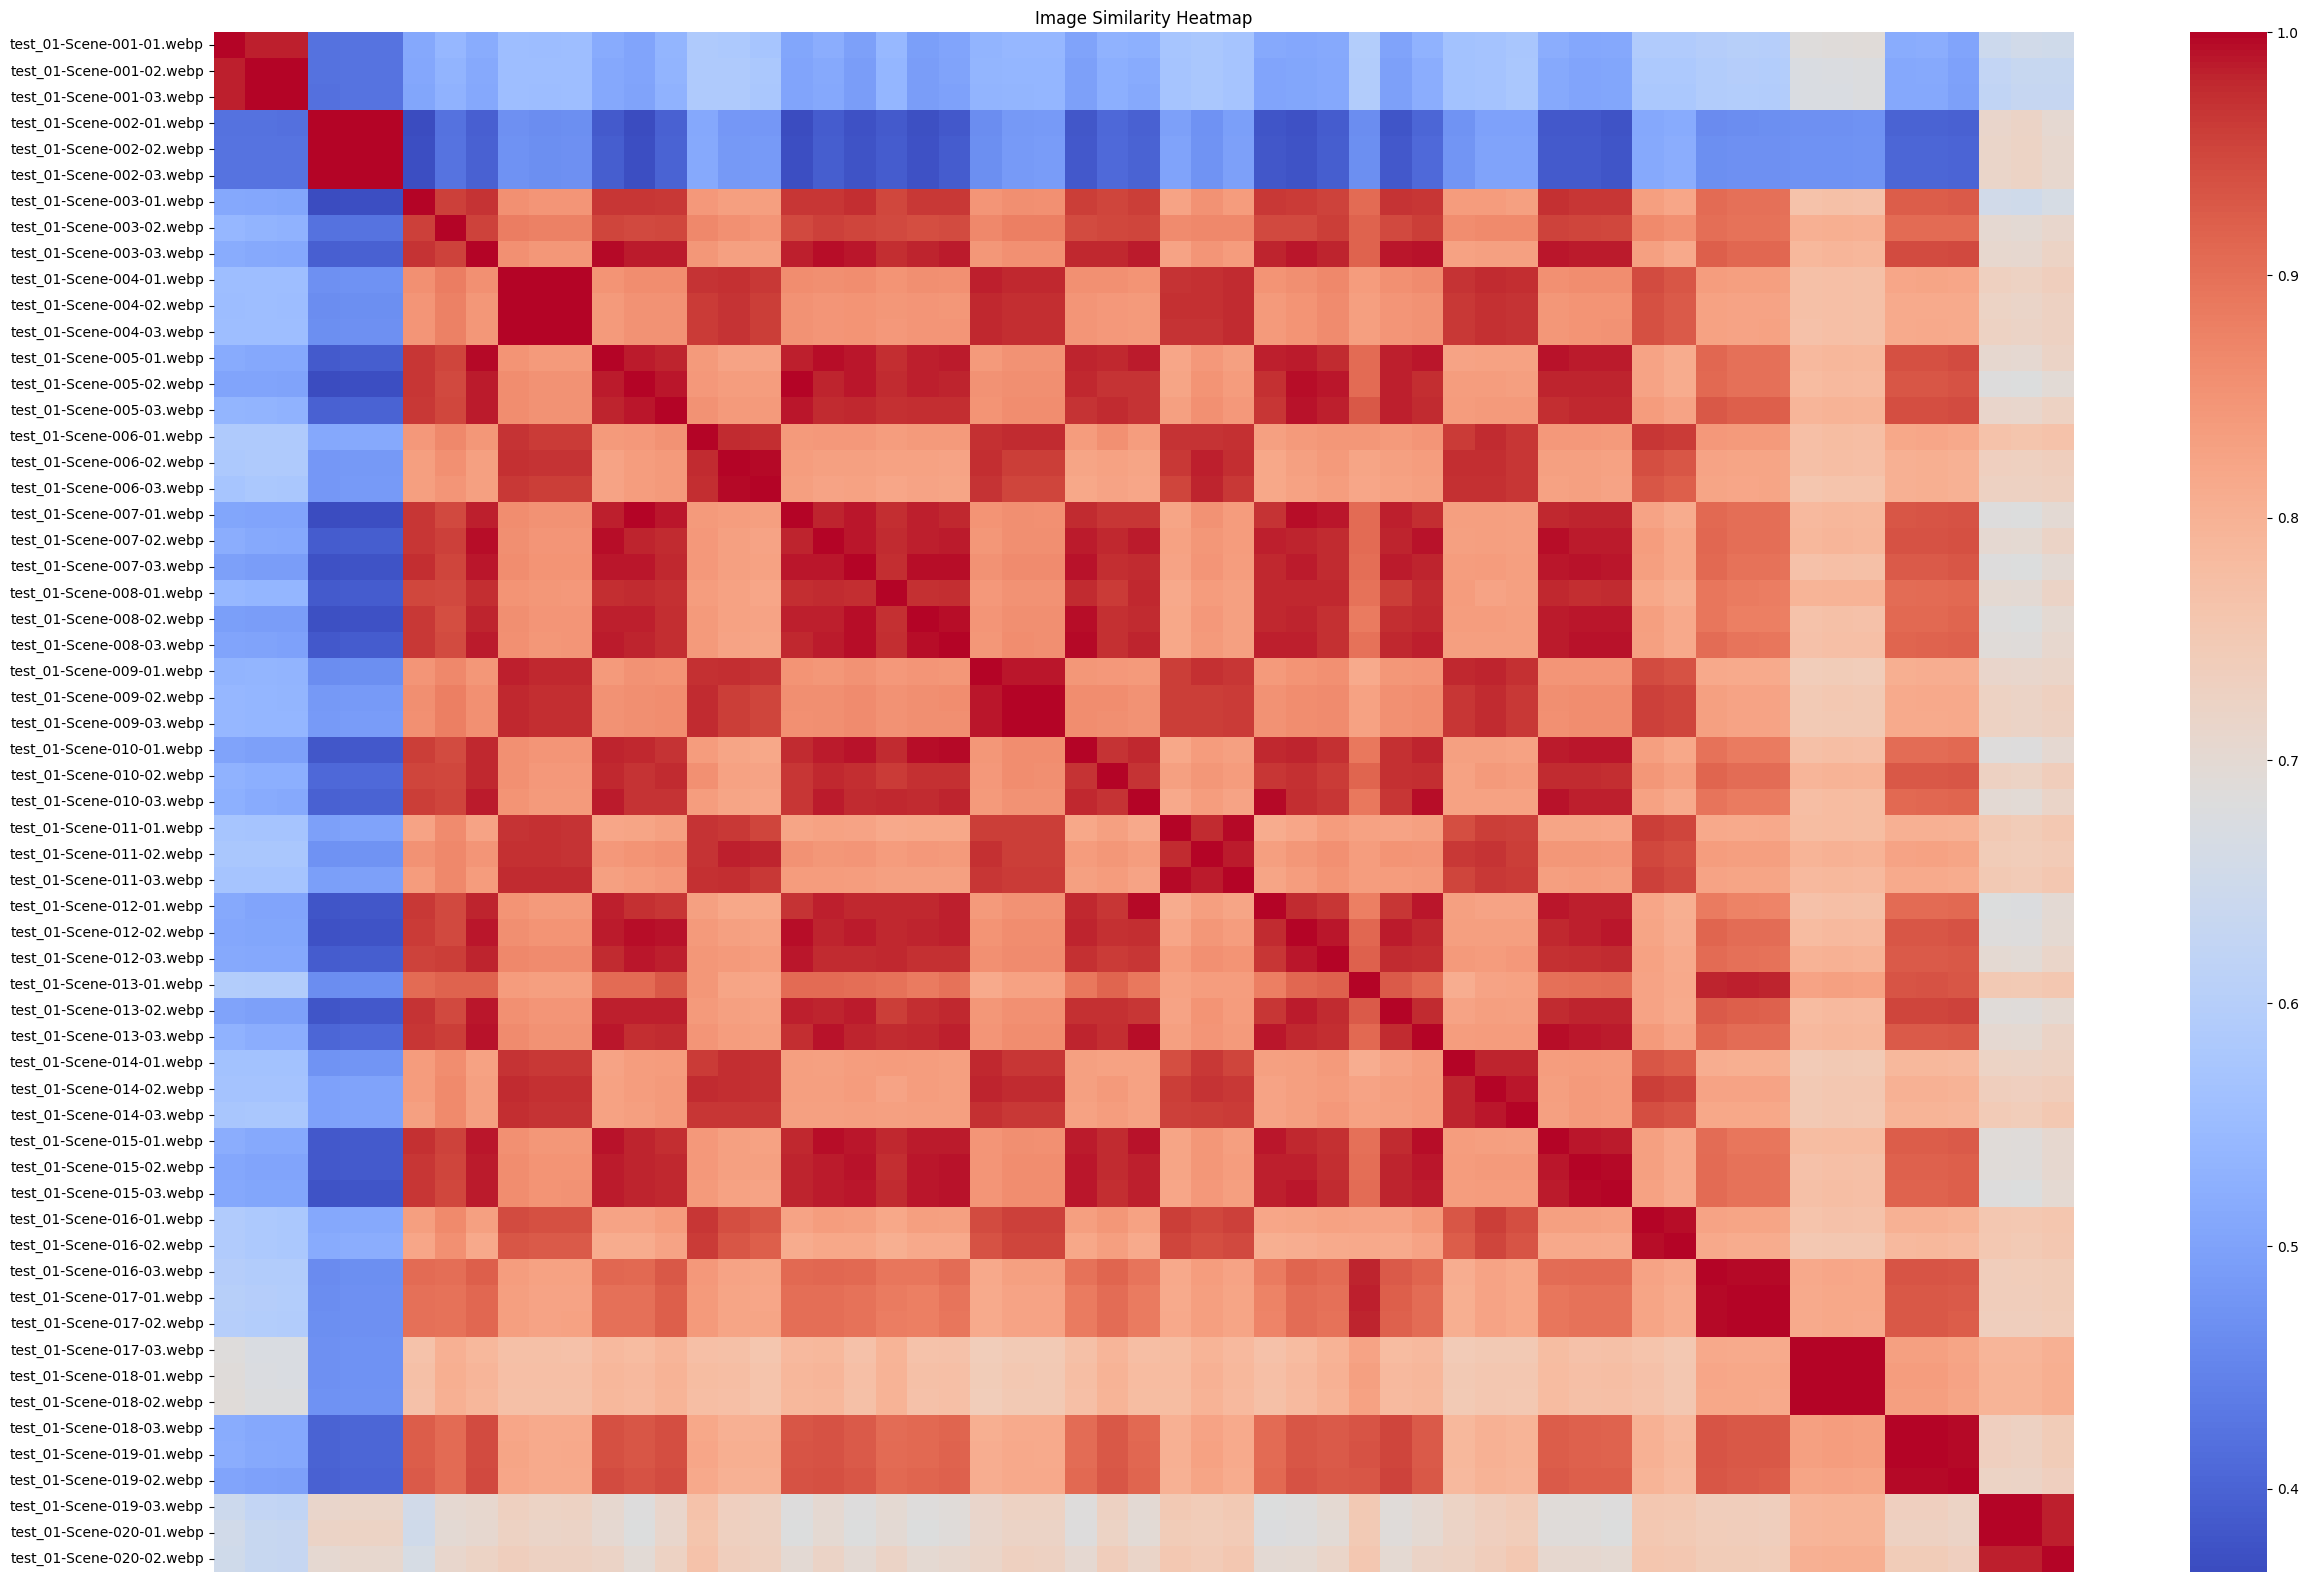

In [105]:
plt.figure(figsize=(30, 20)) 
sns.heatmap(similarity_matrix, xticklabels=False, yticklabels=image_files, annot=False, cmap="coolwarm")
plt.title("Image Similarity Heatmap")
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8e809eb8-650a-4468-a096-2a2830a4a1e1' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>